In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [58]:
df = pd.read_csv('train-selected-columns.csv')

In [59]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500


In [60]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [61]:
df.shape

(891, 10)

In [62]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [63]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [64]:
y = df['Survived']
x = df.drop('Survived',axis=1)

In [65]:
x = x.drop(['Name','Ticket','PassengerId'],axis=1)

In [145]:
x['Age'] = z_score_normalize(x['Age'])
x['Fare'] = z_score_normalize(x['Fare'])

In [146]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,-0.565736,1,0,-0.502445
1,1,1,0.663861,1,0,0.786845
2,3,1,-0.258337,0,0,-0.488854
3,1,1,0.433312,1,0,0.420730
4,3,0,0.433312,0,0,-0.486337


In [147]:
m,n = x.shape

In [148]:
train_range = int(m * 0.9)

In [149]:
train_range

801

In [150]:
x_train, y_train = np.array(x[:train_range]), np.array(y[:train_range]).reshape(-1,1)
x_test, y_test = np.array(x[train_range:]), np.array(y[train_range:]).reshape(-1,1)

In [151]:
x_test.shape

(90, 6)

In [152]:
def z_score_normalize(col):
    return (col - np.mean(col))/np.std(col)

In [153]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [154]:
def loss(y_pred, y,m):
    epsilon = 1e-9
    loss = -1/m * np.sum(y*np.log(y_pred+epsilon) + (1-y)*np.log(1-y_pred + epsilon))
    return loss

In [155]:
def LogisticRegression(x,y,lr=0.0001,epochs=100):
    w = np.zeros(n).reshape(-1,1)
    b = 0
    m = x.shape[0]
    loss_history = []
    for _ in range(epochs):
        y_pred = sigmoid(x.dot(w) + b)
        error = y_pred - y
        loss_history.append(loss(y_pred, y, m))
        dj_dw = 1/m * x.T.dot(error)
        dj_db = 1/m * np.sum(error)
        w -= lr*dj_dw
        b -= lr*dj_db
    return w, b, loss_history
    
        

In [198]:
w,b,loss_history = LogisticRegression(x_train, y_train, 1.5, 10000)
loss_history[-1]

np.float64(0.4445278981374372)

In [201]:

z_test = np.dot(x_test, w) + b
probabilities = sigmoid(z_test)


predictions = (probabilities >= 0.5).astype(int)

In [204]:
accuracy = np.mean(predictions == y_test) * 100
print(f"Test Split Accuracy: {accuracy:.2f}%")

Test Split Accuracy: 83.33%


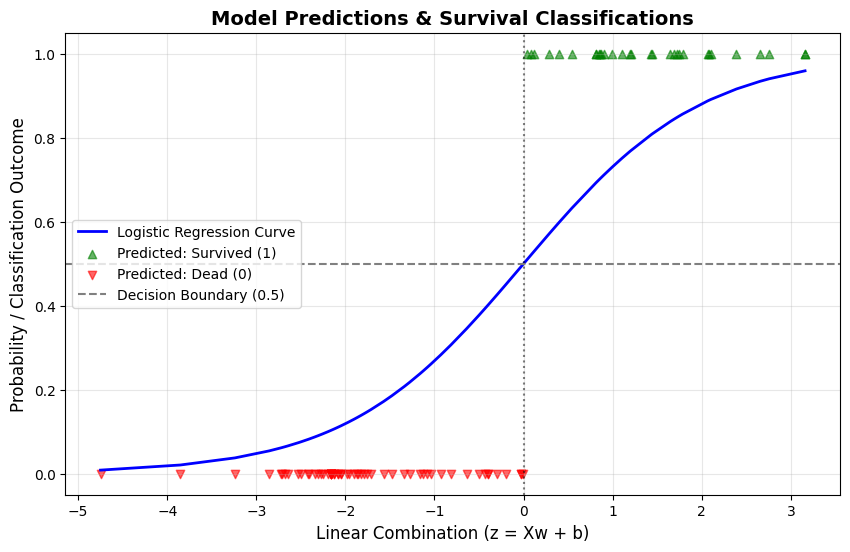

In [206]:
import matplotlib.pyplot as plt

# 1. Compute the raw line equations (z) and probabilities for your validation set
z_test = np.dot(x_test, w) + b
probabilities = sigmoid(z_test)

# 2. Sort the values by z so the sigmoid curve plots smoothly line-by-line
sort_idx = np.argsort(z_test.flatten())
z_sorted = z_test.flatten()[sort_idx]
prob_sorted = probabilities.flatten()[sort_idx]
pred_sorted = predictions.flatten()[sort_idx]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the continuous Sigmoid Probability Curve
plt.plot(z_sorted, prob_sorted, color='blue', label='Logistic Regression Curve', linewidth=2)

# Scatter plot the actual classifications (color-coded by survival outcome)
plt.scatter(z_sorted[pred_sorted == 1], pred_sorted[pred_sorted == 1], 
            color='green', marker='^', alpha=0.6, label='Predicted: Survived (1)')
plt.scatter(z_sorted[pred_sorted == 0], pred_sorted[pred_sorted == 0], 
            color='red', marker='v', alpha=0.6, label='Predicted: Dead (0)')

# Add the 0.5 Decision Boundary Threshold line
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.axvline(0.0, color='black', linestyle=':', alpha=0.5) # z=0 corresponds to prob=0.5

# Labels and Styling
plt.title('Model Predictions & Survival Classifications', fontsize=14, fontweight='bold')
plt.xlabel('Linear Combination (z = Xw + b)', fontsize=12)
plt.ylabel('Probability / Classification Outcome', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='center left')

plt.show()